### LangChain

In [79]:
# %pip install -U langchain langchain-openai

from pathlib import Path
import httpx2
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI
from rich import print
from pydantic import SecretStr


In [80]:
def print_response(response: AIMessage):
    print(f'Response id: {response.id}')
    if response.usage_metadata is not None:
        input_tokens = response.usage_metadata.get('input_tokens', 0)
        cached_tokens = response.usage_metadata.get('input_token_details', {}).get('cache_read', 0)
        output_tokens = response.usage_metadata.get('output_tokens', 0)
        reasoning_tokens = response.usage_metadata.get('output_token_details', {}).get('reasoning', 0)

        print(f'Input tokens: {input_tokens} ({cached_tokens} cached); Output tokens: {output_tokens} ({reasoning_tokens} reasoning)')

    print()
    print(f"{'-' * 20} [Output] {'-' * 20}")
    print(response.text)

In [81]:
openai_api_key = SecretStr(Path('openai-secret-key-ai-integrations-developers.txt').read_text(encoding='utf-8').strip())
# trust_env=False bypasses the broken local proxy configured in this environment.
openai_model = ChatOpenAI(
    model_name='gpt-5-nano',
    openai_api_key=openai_api_key,
    reasoning_effort='low',
    http_client=httpx2.Client(trust_env=False),
)

In [82]:
messages = [
SystemMessage(content="You are a helpful assistant that translates English to French."),
HumanMessage(content="Translate the following English text to French: 'Hello, how are you?'")
]

In [83]:
response = openai_model.invoke(
    input= messages
)

In [84]:
print_response(response)

Response id: lc_run--01a07730-f469-72c1-9825-13abfd816331-0

Input tokens: 36 (0 cached); Output tokens: 79 (64 reasoning)

-------------------- [Output] --------------------

Bonjour, comment ça va ?

In [85]:
from pydantic import BaseModel

class WorkshopBrief(BaseModel): 
    title:str
    audience: str
    duration_minutes:float
    key_takeaways: list[str]

openai_astructured_output_model = openai_model.with_structured_output(WorkshopBrief)

In [86]:
response = openai_astructured_output_model.invoke(
    input=[
        SystemMessage("You are en expert event organizer"), 
        HumanMessage("Design a beginner-friendly Saturday workshop about balcony herb gardening")
    ]
)
print(response)

WorkshopBrief(
    title="Beginner's Balcony: Quick Start to Herb Gardening",
    audience='Absolute beginners with limited space, urban dwellers, and weekend gardeners who want to grow herbs 
on a sunny balcony',
    duration_minutes=120.0,
    key_takeaways=[
        'Understand light requirements for common balcony herbs (basil, parsley, chives, mint) and plan your space 
accordingly',
        'Choose the right containers, soil mix, and drainage for container gardening',
        'Step-by-step planting: seed vs. starter plant, spacing, and initial care',
        'Simple watering routine and how to check for proper moisture without overwatering',
        'Mulching, fertilizing basics, and organic pest management suitable for small balconies',
        'Practical setup: low-cost, scalable container arrangements (vertical, railing, and hanging options)',
        'Basic maintenance calendar: weekly checks, pruning techniques, and seasonal adjustments'
    ]
)

### Tools

In [87]:
from langchain_core.tools import tool

In [88]:
@tool
def get_database_status(): 
    """Returns information about the current dataase status"""
    return "healthy"

In [89]:
# Give the chat model permission to request this Python function as a tool.
openai_model_with_tools = openai_model.bind_tools([get_database_status])

# Start a new conversation. Keeping this list fresh prevents reuse of old tool-call IDs.
messages = [
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content="Check the database status."),
]

# Ask the model for its next step. It can either answer normally or request one or more tools.
ai_message = openai_model_with_tools.invoke(messages)
messages.append(ai_message)

# Run every tool the model requested.
for tool_call in ai_message.tool_calls:
    # Pass the arguments selected by the model to the matching Python tool.
    tool_result = get_database_status.invoke(tool_call["args"])

    # Send the result back using the exact ID from this assistant message.
    # This ID links the result to the tool request and avoids an invalid-request error.
    messages.append(
        ToolMessage(content=str(tool_result), tool_call_id=tool_call["id"])
    )

# The model now reads the tool result and writes its final user-facing answer.
final_response = openai_model_with_tools.invoke(messages)
print_response(final_response)


Response id: lc_run--01a07731-0771-7fe0-9531-f6f30b0859fa-0

Input tokens: 163 (0 cached); Output tokens: 13 (0 reasoning)

-------------------- [Output] --------------------

The database status is healthy. No action required.

In [90]:
from typing import List
from langchain_core.messages import BaseMessage

# Maps each tool name requested by the model to its Python implementation.
tools_registry = {get_database_status.name: get_database_status}


def run_agent_loop(conversation: List[BaseMessage]):
    MAX_ITERATIONS = 100
    finished_successfully = False

    for _ in range(MAX_ITERATIONS):
        # The model either produces a final answer or requests one or more tools.
        reply = openai_model_with_tools.invoke(conversation)
        conversation.append(reply)

        # No tool calls means the model has finished the conversation.
        if not reply.tool_calls:
            finished_successfully = True
            break

        # Run every requested tool and add its result to the conversation.
        for tool_call in reply.tool_calls:
            tool_call_id = tool_call["id"]
            tool_call_name = tool_call["name"]
            tool_call_args = tool_call["args"]

            result = tools_registry[tool_call_name].invoke(tool_call_args)
            conversation.append(
                ToolMessage(content=str(result), tool_call_id=tool_call_id)
            )

    # Stop a runaway loop instead of repeatedly calling the API forever.
    if not finished_successfully:
        raise RuntimeError(
            f"Could not finish the interaction within {MAX_ITERATIONS} iterations."
        )

    return conversation


In [91]:
def print_conversation(conversation: List[BaseMessage]):
    """Print messages, including every LLM tool decision and tool result."""
    for index, message in enumerate(conversation, start=1):
        print(f"\n[bold cyan]Message {index} — {message.type.upper()}[/bold cyan]")

        # AI messages may contain normal text, tool calls, or both.
        if isinstance(message, AIMessage) and message.tool_calls:
            print("[bold yellow]The LLM decided to call tool(s):[/bold yellow]")
            for tool_call in message.tool_calls:
                print(f"  [yellow]Tool:[/yellow] {tool_call['name']}")
                print(f"  [yellow]Arguments:[/yellow] {tool_call['args']}")
                print(f"  [dim]Tool-call ID: {tool_call['id']}[/dim]")

            if message.content:
                print(f"[bold]LLM text:[/bold] {message.content}")

        # A ToolMessage is the Python tool's result sent back to the LLM.
        elif isinstance(message, ToolMessage):
            print(f"[bold green]Tool result:[/bold green] {message.content}")
            print(f"[dim]For tool-call ID: {message.tool_call_id}[/dim]")

        # System and human messages, plus final plain LLM answers, show their content.
        else:
            print(message.content)


In [92]:
from datetime import datetime
from zoneinfo import ZoneInfo


@tool
def get_current_time(timezone: str) -> str:
    """Return the current date and time for an IANA timezone, for example 'Europe/Sofia'."""
    # ZoneInfo converts the supplied timezone name into the requested local time.
    return datetime.now(ZoneInfo(timezone)).strftime("%Y-%m-%d %H:%M:%S %Z")


@tool
def multiply_numbers(first_number: float, second_number: float) -> float:
    """Multiply two numbers and return the result."""
    # This is a local Python calculation; it does not call an external service.
    return first_number * second_number


In [93]:
# Put all tools in one list so they can be passed to the model together.
learning_tools = [get_database_status, get_current_time, multiply_numbers]

# The registry lets the agent loop find and run a requested tool by its name.
tools_registry = {tool.name: tool for tool in learning_tools}

# 'auto' lets the model decide whether to answer directly or request a suitable tool.
# It does not force a tool call on every prompt.
openai_model_with_tools = openai_model.bind_tools(
    learning_tools,
    tool_choice="auto",
)


In [94]:
# Example 1: ask a question that requires the database-status tool.
# Run the cells that define the tools and run_agent_loop before running this cell.
database_conversation = [
    SystemMessage(content="You are a helpful operations assistant. Use tools when needed."),
    HumanMessage(content="Use the database-status tool and tell me whether the database is healthy."),
]

# The loop asks the model, runs any tool calls, and asks the model for a final answer.
run_agent_loop(database_conversation)
print_conversation(database_conversation)

# Example 2: the model can make more than one tool call before it answers.
time_and_math_conversation = [
    SystemMessage(content="You are a helpful assistant. Use the requested tools."),
    HumanMessage(
        content=(
            "Use get_current_time for Europe/Sofia and multiply_numbers for 12 and 7. "
            "Then summarize both results."
        )
    ),
]

run_agent_loop(time_and_math_conversation)
print_conversation(time_and_math_conversation)

# Example 3: with tool_choice='auto', the model can answer without calling a tool.
normal_conversation = [
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content="Explain what an API is in one sentence."),
]

run_agent_loop(normal_conversation)
print_conversation(normal_conversation)


Message 1 — SYSTEM

You are a helpful operations assistant. Use tools when needed.

Message 2 — HUMAN

Use the database-status tool and tell me whether the database is healthy.

Message 3 — AI

...

You are a helpful assistant.

Message 2 — HUMAN

Explain what an API is in one sentence.

Message 3 — AI

An API is a set of rules and tools that allows one software program to interact with another by requesting services
or data.

In [95]:
# Run once in the notebook kernel. These packages power the two retrievers below.
%pip install -U wikipedia arxiv


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [96]:
import wikipedia
from langchain_community.retrievers import ArxivRetriever, WikipediaRetriever

# Wikipedia rejects anonymous/default clients. Replace the contact address before sharing this project.
wikipedia.set_user_agent(
    "SoftUniAIAgents/1.0 (educational project; contact: your-email@example.com)"
)

# WikipediaRetriever searches Wikipedia articles and returns LangChain Document objects.
wikipedia_retriever = WikipediaRetriever(
    top_k_results=2,
    doc_content_chars_max=1_500,
)

# ArxivRetriever searches research-paper abstracts from arXiv.
arxiv_retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=False,  # False returns abstracts instead of downloading full PDFs.
)


def print_documents(documents):
    """Print a compact, readable preview of retrieved LangChain Documents."""
    for number, document in enumerate(documents, start=1):
        title = document.metadata.get("title", "Untitled document")
        print(f"\n[bold cyan]Document {number}: {title}[/bold cyan]")
        print(document.page_content[:600])


In [97]:
# Example 1: retrieve general background information from Wikipedia.
wikipedia_documents = wikipedia_retriever.invoke("retrieval-augmented generation")
print_documents(wikipedia_documents)


Document 1: Retrieval-augmented generation

Retrieval-augmented generation (RAG) is a technique that enables large language models (LLMs) to retrieve and 
incorporate new information from external data sources. With RAG, LLMs first refer to a specified set of documents,
then respond to user queries. These documents supplement information from the LLM's pre-existing training data. 
This allows LLMs to use domain-specific and/or updated information that is not available in the training data. For 
example, this enables LLM-based chatbots to access internal company data or generate responses based on 
authoritative sources. The technique was fi

Document 2: Vector database

A vector database, vector store or vector search engine is a database that stores and retrieves embeddings of data 
in vector space. Vector databases typically implement approximate nearest neighbor algorithms so users can search 
for records semantically similar to a given input, unlike traditional databases which primarily look up records by 
exact match. Use-cases for vector databases include similarity search, semantic search, multi-modal search, 
recommendations engines, object detection, and retrieval-augmented generation (RAG).
Vector embeddings are mathematical representations of data in a

In [98]:
# # Example 2: retrieve recent research-paper abstracts from arXiv.
# arxiv_documents = arxiv_retriever.invoke("large language model agents")
# print_documents(arxiv_documents)


In [99]:
@tool
def search_wikipedia(query: str) -> str:
    """Search Wikipedia for a topic and return relevant article excerpts."""
    # The retriever returns Document objects. Limit each excerpt to keep the tool result concise.
    documents = wikipedia_retriever.invoke(query)

    if not documents:
        return "No Wikipedia results were found."

    return "\n\n".join(
        f"Title: {document.metadata.get('title', 'Untitled')}\n"
        f"Excerpt: {document.page_content[:1_000]}"
        for document in documents
    )


# Add the retrieval tool to the existing local tools.
learning_tools = [
    get_database_status,
    get_current_time,
    multiply_numbers,
    search_wikipedia,
]

# Rebuild both objects so the agent loop can find and call the new tool.
tools_registry = {tool.name: tool for tool in learning_tools}
openai_model_with_tools = openai_model.bind_tools(
    learning_tools,
    tool_choice="auto",
)


In [100]:
# Example: the model decides to call search_wikipedia, then summarizes the retrieved excerpts.
wikipedia_tool_conversation = [
    SystemMessage(content="You are a research assistant. Use Wikipedia when current context is needed."),
    HumanMessage(content="Use Wikipedia to explain retrieval-augmented generation in two sentences."),
]

run_agent_loop(wikipedia_tool_conversation)
print_conversation(wikipedia_tool_conversation)


Message 1 — SYSTEM

You are a research assistant. Use Wikipedia when current context is needed.

Message 2 — HUMAN

Use Wikipedia to explain retrieval-augmented generation in two sentences.

Message 3 — AI

...

Message 4 — TOOL

Tool result: Title: Retrieval-augmented generation
Excerpt: Retrieval-augmented generation (RAG) is a technique that enables large language models (LLMs) to retrieve 
and incorporate new information from external data sources. With RAG, LLMs first refer to a specified set of 
documents, then respond to user queries. These documents supplement information from the LLM's pre-existing 
training data. This allows LLMs to use domain-specific and/or updated information that is not available in the 
training data. For example, this enables LLM-based chatbots to access internal company data or generate responses 
based on authoritative sources. The technique was first proposed in 2020 and has since become a widely adopted 
approach in modern AI systems.
RAG improves LLMs by incorporating information retrieval before generating responses. Unlike LLMs that rely on 
static training data, RAG pulls relevant text from databases, uploaded documents, or web sources. According to Ars 
Technica, "RAG is a way of improving LLM performance, in essence by blending the LLM

Title: Vector database
Excerpt: A vector database, vector store or vector search engine is a database that stores and retrieves embeddings
of data in vector space. Vector databases typically implement approximate nearest neighbor algorithms so users can 
search for records semantically similar to a given input, unlike traditional databases which primarily look up 
records by exact match. Use-cases for vector databases include similarity search, semantic search, multi-modal 
search, recommendations engines, object detection, and retrieval-augmented generation (RAG).
Vector embeddings are mathematical representations of data in a high-dimensional space. In this space, each 
dimension corresponds to a feature of the data, with the number of dimensions ranging from a few hundred to tens of
thousands, depending on the complexity of the data being represented. Each data item is represented by one vector 
in this space. Words, phrases, or entire documents, as well as images, audio, and other types of data, can all be 
vectorized.

For tool-call ID: call_HhD4BdVcx8ia8OCSWmWPMEtC

Message 5 — AI

Retrieval-augmented generation (RAG) is a technique that enables large language models to retrieve and incorporate 
information from external data sources. In RAG, the model first retrieves relevant documents from a chosen corpus 
or web sources and uses that material to supplement its generated responses, allowing access to domain-specific or 
updated information beyond its training data.

In [101]:
# Run once in the notebook kernel. PyPDFLoader uses pypdf to read PDF files.
%pip install -U pypdf


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [102]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Change this path when you want to load a different PDF from the notebook folder.
pdf_path = Path("The_Happy_Prince_and_Other_Tales_by_Oscar_Wilde.pdf")

# PyPDFLoader returns one LangChain Document per PDF page, including page metadata.
pdf_loader = PyPDFLoader(str(pdf_path))
pdf_pages = pdf_loader.load()
print(f"Loaded {len(pdf_pages)} pages from: {pdf_path.name}")

# Split long pages into chunks. The splitter first tries natural boundaries
# (paragraphs, lines, and spaces) before falling back to individual characters.
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1_000,
    chunk_overlap=200,  # Preserves context between neighboring chunks.
)
pdf_chunks = text_splitter.split_documents(pdf_pages)

print(f"Created {len(pdf_chunks)} recursive text chunks.")
print(f"First chunk comes from page: {pdf_chunks[0].metadata.get('page', 0) + 1}")
print(pdf_chunks[0].page_content[:500])


Loaded 78 pages from: The_Happy_Prince_and_Other_Tales_by_Oscar_Wilde.pdf

Created 161 recursive text chunks.

First chunk comes from page: 2

The Project Gutenberg eBook of The Happy
Prince, and Other Tales
This eBook is for the use of anyone anywhere in the United States and most
other parts of the world at no cost and with almost no restrictions whatsoever.
You may copy it, give it away or re-use it under the terms of the Project
Gutenberg License included with this eBook or online at www.gutenberg.org.
If you are not located in the United States, you will have to check the laws of
the country where you are located before using this

In [103]:
# Run once in the notebook kernel. langchain-chroma connects LangChain to Chroma.
%pip install -U chromadb langchain-chroma


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

# Turn each PDF chunk into an embedding: a vector that represents its meaning.
embeddings = OpenAIEmbeddings(
    api_key=openai_api_key,
    # Use the same direct HTTPS connection as the chat model.
    http_client=httpx2.Client(trust_env=False),
)

# Chroma stores the chunks and their vectors on disk so they can be reused later.
chroma_directory = "chroma_db_happy_prince"
pdf_vector_store = Chroma.from_documents(
    documents=pdf_chunks,
    embedding=embeddings,
    collection_name="happy_prince_pdf",
    persist_directory=chroma_directory,
)

print(f"Stored {len(pdf_chunks)} PDF chunks in: {chroma_directory}")


Stored 161 PDF chunks in: chroma_db_happy_prince

In [105]:
# Similarity search returns chunks that are semantically related to the question.
question = "What is the Happy Prince's appearance?"
matching_chunks = pdf_vector_store.similarity_search(question, k=3)

print_documents(matching_chunks)


Document 1: The Happy Prince, and Other Tales

The Happy Prince.
H IGH above the city, on a tall column, stood the statue of the Happy
Prince. He was gilded all over with thin leaves of fine gold, for eyes he had
two bright sapphires, and a large red ruby glowed on his sword-hilt.
He was very much admired indeed. “He is as beautiful as a
weathercock,” remarked one of the Town Councillors who wished to gain a
reputation for having artistic tastes; “only not quite so useful,” he added,
fearing lest people should think him unpractical, which he really was not.
“Why can’t you be like the Happy Prince?” asked a sensible mother of
her little boy

Document 2: The Happy Prince, and Other Tales

The Happy Prince.
H IGH above the city, on a tall column, stood the statue of the Happy
Prince. He was gilded all over with thin leaves of fine gold, for eyes he had
two bright sapphires, and a large red ruby glowed on his sword-hilt.
He was very much admired indeed. “He is as beautiful as a
weathercock,” remarked one of the Town Councillors who wished to gain a
reputation for having artistic tastes; “only not quite so useful,” he added,
fearing lest people should think him unpractical, which he really was not.
“Why can’t you be like the Happy Prince?” asked a sensible mother of
her little boy

Document 3: The Happy Prince, and Other Tales

The Happy Prince.
H IGH above the city, on a tall column, stood the statue of the Happy
Prince. He was gilded all over with thin leaves of fine gold, for eyes he had
two bright sapphires, and a large red ruby glowed on his sword-hilt.
He was very much admired indeed. “He is as beautiful as a
weathercock,” remarked one of the Town Councillors who wished to gain a
reputation for having artistic tastes; “only not quite so useful,” he added,
fearing lest people should think him unpractical, which he really was not.
“Why can’t you be like the Happy Prince?” asked a sensible mother of
her little boy

In [106]:
# Convert the vector store into LangChain's standard Retriever interface.
# The retriever can now be used in RAG chains, agents, or directly with .invoke().
pdf_retriever = pdf_vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3},  # Return the three most relevant PDF chunks.
)

# A retriever takes a text query and returns a list of matching Document objects.
retrieved_documents = pdf_retriever.invoke(
    "What is the Happy Prince's appearance?"
)
print_documents(retrieved_documents)


Document 1: The Happy Prince, and Other Tales

The Happy Prince.
H IGH above the city, on a tall column, stood the statue of the Happy
Prince. He was gilded all over with thin leaves of fine gold, for eyes he had
two bright sapphires, and a large red ruby glowed on his sword-hilt.
He was very much admired indeed. “He is as beautiful as a
weathercock,” remarked one of the Town Councillors who wished to gain a
reputation for having artistic tastes; “only not quite so useful,” he added,
fearing lest people should think him unpractical, which he really was not.
“Why can’t you be like the Happy Prince?” asked a sensible mother of
her little boy

Document 2: The Happy Prince, and Other Tales

The Happy Prince.
H IGH above the city, on a tall column, stood the statue of the Happy
Prince. He was gilded all over with thin leaves of fine gold, for eyes he had
two bright sapphires, and a large red ruby glowed on his sword-hilt.
He was very much admired indeed. “He is as beautiful as a
weathercock,” remarked one of the Town Councillors who wished to gain a
reputation for having artistic tastes; “only not quite so useful,” he added,
fearing lest people should think him unpractical, which he really was not.
“Why can’t you be like the Happy Prince?” asked a sensible mother of
her little boy

Document 3: The Happy Prince, and Other Tales

The Happy Prince.
H IGH above the city, on a tall column, stood the statue of the Happy
Prince. He was gilded all over with thin leaves of fine gold, for eyes he had
two bright sapphires, and a large red ruby glowed on his sword-hilt.
He was very much admired indeed. “He is as beautiful as a
weathercock,” remarked one of the Town Councillors who wished to gain a
reputation for having artistic tastes; “only not quite so useful,” he added,
fearing lest people should think him unpractical, which he really was not.
“Why can’t you be like the Happy Prince?” asked a sensible mother of
her little boy

### Agents

In [107]:
from langchain.agents import create_agent

# create_agent builds the tool-calling loop for us. Unlike run_agent_loop(),
# we do not manually inspect tool calls or create ToolMessage objects.
simple_agent = create_agent(
    model=openai_model,
    tools=[get_current_time, multiply_numbers],
    system_prompt=(
        "You are a helpful assistant. Use a tool whenever it is useful, "
        "and clearly explain the final result."
    ),
)


In [108]:
# The agent chooses the necessary tools, runs them, and returns the complete message history.
agent_result = simple_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "What time is it in Europe/Sofia? Also multiply 12.5 by 8."
                ),
            }
        ]
    }
)

# This shows the agent's tool calls, arguments, tool results, and final answer.
print_conversation(agent_result["messages"])


Message 1 — HUMAN

What time is it in Europe/Sofia? Also multiply 12.5 by 8.

Message 2 — AI

The LLM decided to call tool(s):

Tool: get_current_time

...

Message 4 — TOOL

Tool result: 100.0

For tool-call ID: call_Frt7LPHQIWPtSOhayf1dG0vy

Message 5 — AI

- Time in Europe/Sofia: 2026-09-06 17:49:04 EEST (UTC+3)
- 12.5 × 8 = 100.0

In [109]:
from IPython.display import Image, display
from langchain_core.runnables import Runnable


def display_graph(runnable: Runnable, output_png: Path) -> None:
    """Render a LangChain runnable graph, save it as a PNG, and display it."""
    graph = runnable.get_graph()

    try:
        # Render with Mermaid.ink. Empty proxy values avoid the broken local proxy.
        png_bytes = graph.draw_mermaid_png(
            proxies={"http": "", "https": ""},
            max_retries=3,
            retry_delay=2.0,
        )
        output_png.write_bytes(png_bytes)
        display(Image(filename=str(output_png)))

    except ValueError as error:
        # A useful fallback: save Mermaid text, which can be pasted into mermaid.live.
        mermaid_file = output_png.with_suffix(".mmd")
        mermaid_file.write_text(graph.draw_mermaid(), encoding="utf-8")
        print(f"PNG rendering failed: {error}")
        print(f"Saved Mermaid diagram text to: {mermaid_file}")


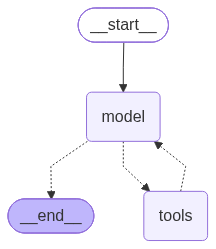

In [110]:
display_graph(simple_agent, Path("simple_agent_graph.png"))

### Agent with memory

In [111]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# Stores conversation state while this notebook kernel is running.
checkpointer = InMemorySaver()

simple_agent_with_memory = create_agent(
    model=openai_model,
    tools=[get_current_time, multiply_numbers],
    system_prompt="You are a helpful assistant.",
    checkpointer=checkpointer,
)

# This ID identifies one conversation.
conversation_config = {
    "configurable": {
        "thread_id": "lesson-1"
    }
}

first_result = simple_agent_with_memory.invoke(
    {
        "messages": [
            {"role": "user", "content": "My name is Maria and I live in Sofia."}
        ]
    },
    config=conversation_config,
)

second_result = simple_agent_with_memory.invoke(
    {
        "messages": [
            {"role": "user", "content": "What city do I live in?"}
        ]
    },
    config=conversation_config,
)

print(second_result["messages"][-1].content)

You live in Sofia. Would you like the current time there or help with anything else?

### Middleware

In [112]:
from collections.abc import Callable
from langchain.agents.middleware import (
    AgentState,
    ModelRequest,
    ModelResponse,
    ToolCallRequest,
    after_agent,
    after_model,
    before_agent,
    before_model,
    wrap_model_call,
    wrap_tool_call,
)
from langchain_core.messages import ToolMessage
from langgraph.runtime import Runtime


# Lifecycle hooks run at named points in the entire agent execution.
@before_agent
def log_before_agent(state: AgentState, runtime: Runtime) -> None:
    # Runs once when agent.invoke() starts.
    print(f"[before_agent] Starting with {len(state['messages'])} message(s).")


@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> None:
    # Runs before every LLM call, including calls made after a tool result.
    print(f"[before_model] Sending {len(state['messages'])} message(s) to the LLM.")


@after_model
def log_after_model(state: AgentState, runtime: Runtime) -> None:
    # Runs after every LLM response. The last message may contain tool calls.
    last_message = state['messages'][-1]
    print(f"[after_model] LLM returned {len(last_message.tool_calls)} tool call(s).")


@after_agent
def log_after_agent(state: AgentState, runtime: Runtime) -> None:
    # Runs once after the agent has produced its final answer.
    print(f"[after_agent] Finished with {len(state['messages'])} total message(s).")


# Wrap hooks run around an operation. Calling handler(request) performs the real work.
@wrap_model_call
def log_model_call(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    print("[wrap_model_call] About to call the LLM.")
    response = handler(request)
    print("[wrap_model_call] LLM call completed.")
    return response


@wrap_tool_call
def log_tool_call(
    request: ToolCallRequest,
    handler: Callable[[ToolCallRequest], ToolMessage],
) -> ToolMessage:
    # request.tool_call contains the tool name and arguments chosen by the LLM.
    print(f"[wrap_tool_call] Calling {request.tool_call['name']} with {request.tool_call['args']}")
    response = handler(request)
    print("[wrap_tool_call] Tool call completed.")
    return response


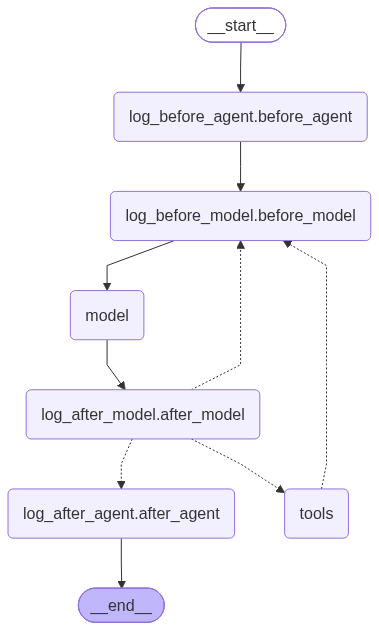

In [113]:
# Pass the middleware functions to create_agent. Their logs reveal the agent's execution flow.
middleware_agent = create_agent(
    model=openai_model,
    tools=[get_current_time, multiply_numbers],
    system_prompt="You are a helpful assistant. Use tools when appropriate.",
    middleware=[
        log_before_agent,
        log_before_model,
        log_after_model,
        log_after_agent,
        log_model_call,
        log_tool_call,
    ],
)

# The graph includes the agent's model, tools, and middleware steps.
display_graph(middleware_agent, Path("middleware_agent_graph.png"))


In [114]:
# Run the agent and watch the middleware logs appear before and after each step.
middleware_result = middleware_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What time is it in Europe/Sofia? Then multiply 9 by 11.",
            }
        ]
    }
)

# Show the complete conversation, including the LLM tool choices and results.
print_conversation(middleware_result["messages"])


Starting with 1 message(s).

Sending 1 message(s) to the LLM.

About to call the LLM.

LLM call completed.

LLM returned 2 tool call(s).

...

Message 4 — TOOL

Tool result: 99.0

For tool-call ID: call_SsTABOKDrYDBDAKdnKaFRCqO

Message 5 — AI

- Current time in Europe/Sofia: 2026-09-06 17:49:10 EEST
- 9 multiplied by 11: 99

In [117]:
from langchain.agents.middleware import PIIMiddleware

# PIIMiddleware runs before the model call, so sensitive input is not sent to the model.
# Redact removes an email entirely; mask keeps only a small part of a card number visible.
pii_redaction_agent = create_agent(
    model=openai_model,
    tools=[],
    system_prompt="You are a helpful assistant. Summarize the user's request safely.",
    middleware=[
        PIIMiddleware(
            "email",
            strategy="redact",
            apply_to_input=True,
            apply_to_output=True,
        ),
        PIIMiddleware(
            "credit_card",
            strategy="mask",
            apply_to_input=True,
            apply_to_output=True,
        ),
    ],
)

# The graph shows the middleware nodes around the agent's model step.
display_graph(pii_redaction_agent, Path("pii_redaction_agent_graph.png"))


PNG rendering failed: Failed to reach https://mermaid.ink API while trying to render your graph. Status code: 400.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., 
draw_method=MermaidDrawMethod.PYPPETEER)`

Saved Mermaid diagram text to: pii_redaction_agent_graph.mmd

In [ ]:
# This uses a public test card number. The middleware masks it before the model receives it.
pii_result = pii_redaction_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "My email is learner@example.com and my test card is "
                    "4242 4242 4242. Please summarize my contact details."
                ),
            }
        ]
    }
)

# Inspect the message history to see the redacted/masked values.
print_conversation(pii_result["messages"])


Message 1 — HUMAN

My email is [REDACTED_EMAIL] and my test card is **** **** **** 4242. Please summarize my contact details.

Message 2 — AI

Summary of your request:
- You asked me to summarize your contact details.
- You provided an email address (redacted) and a masked test card number (4242).

Note: I won’t process or store payment card data. If you want me to summarize or format your contact details, 
please provide the non-sensitive parts (e.g., full name, email, phone, address) and I’ll help compile them.